# Baboon data

Formålet med denne notebook, er at indlæse datasættet, identificer populationer, beregn heterozygositet, site frequency spectrum (SFS) og forbered subsets til at bruge i de følgende notebooks.

**Valg af populationer — baseret på Sørensen et al. (2023):**
Datasættet består af hele-genomsekvenser fra 225 vilde bavianer fordelt på 6 arter og 19 geografiske lokaliteter. Artiklen identificerer 

- **Eastern yellow (Mikumi) vs. Kinda** — tæt genealogisk forbundne
- **Eastern yellow (Mikumi) vs. Southern olive (Tarangire)** — dokumenteret løbende admixture 
- **Western yellow (Mahale/Katavi)** — den eneste baboon-population med input fra tre linjer produkt af yellow, olive og Kinda forfædre


I denne notebook vil jeg komme ind på følgende:

1. Indlæs data
2. Udforsk sample
3. Udvælg populationer
4. Beregn derived counts per population
5. Site Frequency Spectrum (SFS)
6. Heterozygositet per population 
7. Tajima's $D$ 
8. Gem data til efterfølgende notebooks

In [1]:
# Importer nødvendige pakker
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import Graph  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sgkit as sg
from pathlib import Path

DATA_DIR = Path("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR")
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Biologiske konstanter fra Sørensen et al. 2023
MUT_RATE = 0.9e-8   # mutationsrate per site per generation
GEN_TIME = 11       # generationstid i år

print("Imports OK")

Imports OK


## 1. Indlæs data


In [2]:
# loader data for chr20 
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")

variant_allele_counts = sg.count_variant_alleles(ds) # variant_allele_count har shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   # triggers compute
nr_samples = ac.sum(axis=1)  # nr haploid samples (chromosomes)

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


In [3]:
# Antal varianter og samples
print(f"Antal varianter (chr20):   {len(derived_variant_count_df):,}")
print(f"Totalt haploid sample size: {int(nr_samples.max())}  ({int(nr_samples.max())//2} diploide individer)")

Antal varianter (chr20):   2,665,269
Totalt haploid sample size: 454  (227 diploide individer)


## 2. Udforsk samples

Jeg lister alle sample-ID'er og sætte dem til arter og lokaliteter.
Sample-ID'erne følger mønsteret *PD_XXXX*. Artsinformation hentes fra en metadata-tabel fra artiklen af Sørensen et al., 2023.

In [4]:
ds['sample_id'].values

array(['Sci_16066', 'Sci_16098', 'Sci_30877', 'Sci_30977', 'Sci_34449',
       'Sci_34474', 'Sci_38168', 'Sci_97074', 'Sci_97124', 'PD_0067',
       'PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0204',
       'PD_0205', 'PD_0206', 'PD_0207', 'PD_0208', 'PD_0209', 'PD_0210',
       'PD_0211', 'PD_0212', 'PD_0213', 'PD_0214', 'PD_0215', 'PD_0216',
       'PD_0217', 'PD_0218', 'PD_0219', 'PD_0220', 'PD_0221', 'PD_0222',
       'PD_0223', 'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228',
       'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234',
       'PD_0235', 'PD_0236', 'PD_0237', 'PD_0238', 'PD_0239', 'PD_0240',
       'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
       'PD_0267', 'PD_0268', 'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272',
       'PD_0390', 'PD_0391', 'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395',
       'PD_0396', 'PD_0397', 'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401',
       'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_

## 3. Udvælg populationer

Fra Sørensen et al. (2023), Tabel S2: Jeg udfylder listerne med de korrekte sample-ID'er baseret på output ovenfor.

Populationer:
- **Eastern yellow (Mikumi):** Veldefineret østlig population. Min reference-population til to-island-modellen.
- **Kinda (Chunga/Dendro Park):** Tæt beslægtet med western yellow.
- **Southern olive (Tarangire):** Artiklen viser løbende admixture med eastern yellow. 
- **Western yellow (Mahale/Katavi):** Tre-vejs admixture (eastern yellow + olive + Kinda).

In [5]:
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # P. cynocephalus - Eastern Tanzania                                                           
    "yellow_east_mikumi":  ['PD_0268', 'PD_0269','PD_0270', 
                            'PD_0271', 'PD_0272', 'PD_0637',
                            'PD_0687', 'PD_0688','PD_0689', 'PD_0690',
                            'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747',
                            'PD_0748', 'PD_0752', 'PD_0753', 'PD_0754', 
                            'PD_0755','PD_0756', 'PD_0761', 'PD_0762',
                            'PD_0763', 'PD_0764', 'PD_0765','PD_0766',
                            'PD_0767','PD_0768', 'PD_0769','PD_0770',
                            'PD_0771', 'PD_0772', 'PD_0773', 'PD_0774','PD_0775'],
    # P. Kindae - Zambia     
    "kinda":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB', 'PD_0692', 'PD_0693', 'PD_0694', 'PD_0695'],
    # P. Anubis - Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire)
    "olive_south":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0238', 'PD_0239',
                            'PD_0240', 'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265',
                            'PD_0266','PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 
                            'PD_0496', 'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501',
                            'PD_0502', 'PD_0641', 'PD_0642', 'PD_0674', 'PD_0675', 'PD_0676',
                            'PD_0677', 'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682',
                            'PD_0683', 'PD_0684', 'PD_0685', 'PD_0686'],                         
    # P. Cynocephalus - Western Tanzania (Mahale + Katavi)
    "yellow_west_mahale":  ['PD_0228','PD_0229','PD_0230', 'PD_0231',
                            'PD_0232','PD_0233','PD_0234', 'PD_0658', 'PD_0659'],                
    # P. anubis - Gog (Ethiopia)
    "olive_gog":           ['PD_0719', 'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724',
                            'PD_0725', 'PD_0726', 'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730',
                            'PD_0731', 'PD_0732', 'PD_0733', 'PD_0734', 'PD_0735', 'PD_0736',
                            'PD_0737', 'PD_0738' 'PD_0739', 'PD_0740', 'PD_0741', 'PD_0742',
                            'PD_0743', 'PD_0744'],                                          
}


In [6]:
# Udtrækker subsets 
keep = population_map["yellow_east_mikumi"]
mask = ds["sample_id"].isin(keep).values
ds_yellow_east = ds.isel(samples=mask)

keep = population_map["kinda"]
mask = ds["sample_id"].isin(keep).values
ds_kinda = ds.isel(samples=mask)

keep = population_map["olive_south"]
mask = ds["sample_id"].isin(keep).values
ds_olive_south = ds.isel(samples=mask)

keep = population_map["yellow_west_mahale"]
mask = ds["sample_id"].isin(keep).values
ds_yellow_west = ds.isel(samples=mask)

keep = population_map["olive_gog"]
mask = ds["sample_id"].isin(keep).values
ds_olive_gog = ds.isel(samples=mask)

print(f"Eastern yellow: {ds_yellow_east.dims['samples']} samples")
print(f"Kinda:          {ds_kinda.dims['samples']} samples")
print(f"Southern olive: {ds_olive_south.dims['samples']} samples")
print(f"Western yellow: {ds_yellow_west.dims['samples']} samples")
print(f"GOG olive: {ds_olive_gog.dims['samples']} samples")


Eastern yellow: 35 samples
Kinda:          29 samples
Southern olive: 46 samples
Western yellow: 9 samples
GOG olive: 24 samples


/tmp/ipykernel_1333460/1455760514.py:22: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Eastern yellow: {ds_yellow_east.dims['samples']} samples")
/tmp/ipykernel_1333460/1455760514.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Kinda:          {ds_kinda.dims['samples']} samples")
/tmp/ipykernel_1333460/1455760514.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print

## 4. Beregn allele counts per population

Jeg beregner derived variant counts (singletons, doubletons, osv.) for hver population.
Disse counts danner grundlaget for SFS analysen og for at fitte coalescent modeller.

In [7]:
def compute_derived_counts(ds_pop, pop_name="population"):
    """
    Beregner derived allele counts for hver population.
    Returnerer en DataFrame med position, derived_count og nr_samples.
    """
    variant_allele_counts = sg.count_variant_alleles(ds_pop)
    ac         = variant_allele_counts["variant_allele_count"].values
    nr_samples = ac.sum(axis=1)

    df = pd.DataFrame({
        "position":      ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples":    nr_samples,
    })

    # Behold kun segregerende SNPs
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    n  = int(df["nr_samples"].max())
    print(f"{pop_name}: {len(df):,} segregerende SNPs  (n={n} haplotyper = {n//2} individer)")
    return df


df_yellow_east = compute_derived_counts(ds_yellow_east, "Eastern yellow (Mikumi)")
df_kinda       = compute_derived_counts(ds_kinda,       "Kinda")
df_olive_south = compute_derived_counts(ds_olive_south, "Southern olive")
df_yellow_west = compute_derived_counts(ds_yellow_west, "Western yellow (Mahale)")
df_olive_gog = compute_derived_counts(ds_olive_gog, "Olive gog")


Eastern yellow (Mikumi): 868,037 segregerende SNPs  (n=70 haplotyper = 35 individer)
Kinda: 947,644 segregerende SNPs  (n=58 haplotyper = 29 individer)
Southern olive: 764,811 segregerende SNPs  (n=92 haplotyper = 46 individer)
Western yellow (Mahale): 771,964 segregerende SNPs  (n=18 haplotyper = 9 individer)
Olive gog: 591,067 segregerende SNPs  (n=48 haplotyper = 24 individer)


In [8]:
df_yellow_east.head()

,position,derived_count,nr_samples
1,73,7,70
4,149,13,70
7,283,49,70
8,437,5,70
10,471,7,70


In [9]:
df_kinda.head()

,position,derived_count,nr_samples
1,73,16,58
3,148,1,58
5,162,4,58
7,283,8,58
17,654,1,58


In [10]:
df_olive_south.head()

,position,derived_count,nr_samples
4,149,1,92
6,236,22,92
7,283,10,92
9,450,3,92
27,1045,2,92


In [11]:
df_yellow_west.head()

,position,derived_count,nr_samples
2,126,1,18
6,236,1,18
7,283,3,18
16,607,1,18
19,732,2,18


In [12]:
df_olive_gog.head()

,position,derived_count,nr_samples
13,501,2,48
36,1828,5,48
37,1867,2,48
38,1926,5,48
39,1939,5,48


## 5. Site Frequency Spectrum


SFS tæller, hvor mange SNPs der er observeret med $1$ kopi, $2$ kopier, $\dots$, $n-1$ kopier af det derived allel. Formen af SFS afspejler populationshistorien fx. viser en overvægt af singletons tegn på vækst eller selektion.

Jeg beregner den foldede SFS (minor allele frequency) for at undgå polariseringsfejl.

In [13]:
def compute_sfs(df, pop_name="population"):
    """Unfoldet SFS fra derived_count DataFrame."""
    n = int(df["nr_samples"].max())
    sfs = np.zeros(n + 1, dtype=int)
    for k, grp in df.groupby("derived_count"):
        k = int(k)
        if 0 < int(k) < n:
            sfs[k] = len(grp)
    return pd.Series(sfs[1:n], index=range(1, n), name=pop_name)

def fold_sfs(sfs):
    """Folder unfoldet SFS til foldet SFS (minor allele frequency)."""
    n = len(sfs) + 1
    mid = n // 2
    folded = sfs.astype(float).copy()
    for i in range(1, mid):
        folded.iloc[i - 1] = sfs.iloc[i - 1] + sfs.iloc[n - i - 1]
    return folded.iloc[:mid]

sfs_ye = compute_sfs(df_yellow_east, "Eastern yellow")
sfs_ki = compute_sfs(df_kinda,       "Kinda")
sfs_os = compute_sfs(df_olive_south, "Southern olive")
sfs_yw = compute_sfs(df_yellow_west, "Western yellow")
sfs_og = compute_sfs(df_olive_gog, "Olive gog")


sfs_ye_f = fold_sfs(sfs_ye)
sfs_ki_f = fold_sfs(sfs_ki)
sfs_os_f = fold_sfs(sfs_os)
sfs_yw_f = fold_sfs(sfs_yw)
sfs_og_f = fold_sfs(sfs_og)


In [14]:
print("Eastern yellow foldet SFS (første 8 bins):")
print(sfs_ye_f.head(8))

Eastern yellow foldet SFS (første 8 bins):
1    143525.0
2     91209.0
3     63618.0
4     51731.0
5     43849.0
6     35808.0
7     33970.0
8     29311.0
Name: Eastern yellow, dtype: float64


In [15]:
print("kinda foldet SFS (Første 8 bins):")
print(sfs_ki_f.head(8))

kinda foldet SFS (Første 8 bins):
1    162419.0
2    103379.0
3     81053.0
4     63969.0
5     53400.0
6     45029.0
7     39051.0
8     35970.0
Name: Kinda, dtype: float64


In [16]:
print("Southern olive foldet SFS (første 8 bins):")
print(sfs_os_f.head(8))

Southern olive foldet SFS (første 8 bins):
1    137940.0
2     82907.0
3     59448.0
4     44247.0
5     39383.0
6     30926.0
7     26967.0
8     20359.0
Name: Southern olive, dtype: float64


In [17]:
print("Western Yellow foldet SFS (første 8 bins):")
print(sfs_yw_f.head(8))

Western Yellow foldet SFS (første 8 bins):
1    235703.0
2    144320.0
3     94979.0
4     73092.0
5     60189.0
6     50948.0
7     47348.0
8     42298.0
Name: Western yellow, dtype: float64


In [18]:
print("Olive gog foldet SFS (første 8 bins):")
print(sfs_og_f.head(8))

Olive gog foldet SFS (første 8 bins):
1    135986.0
2     81205.0
3     47415.0
4     37809.0
5     31478.0
6     26190.0
7     21573.0
8     19008.0
Name: Olive gog, dtype: float64


## Forventet vs. observeret SFS per population 

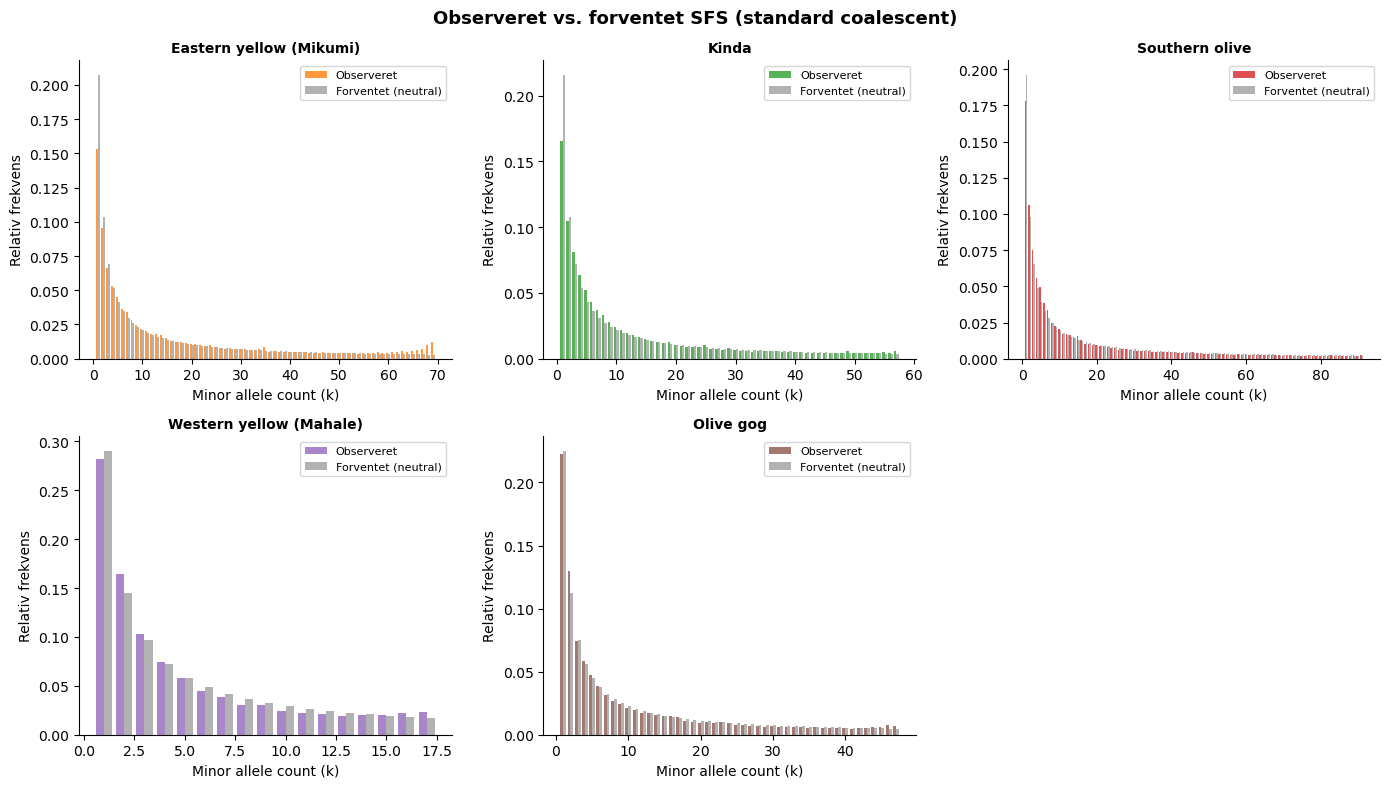

In [30]:
# For hver population: fitter theta med MoM og sammenlign forventet SFS med observeret
pop_names = {
    "Eastern yellow (Mikumi)": (df_yellow_east, sfs_ye, "C1"),
    "Kinda":                   (df_kinda, sfs_ki, "C2"),
    "Southern olive":          (df_olive_south, sfs_os, "C3"),
    "Western yellow (Mahale)": (df_yellow_west, sfs_yw, "C4"),
    "Olive gog":               (df_olive_gog, sfs_og, "C5"),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

pop_items = list(pop_names.items())
for ax_idx, (name, (df_pop, sfs_obs, color)) in enumerate(pop_items):
    ax = axes[ax_idx]
    pi_val = pi_df.loc[name, "pi"]
    Ne_ref = pi_val / (4 * MUT_RATE)

    theta_pi = pi_val  # pi ≈ theta for panmiktisk population

    x = np.arange(1, len(sfs_obs) + 1)
    # Normaliser begge til frekvenser
    obs_norm = sfs_obs.values / sfs_obs.values.sum()
    exp_sfs = np.array([1/k for k in x])
    exp_norm = exp_sfs / exp_sfs.sum()

    ax.bar(x - 0.2, obs_norm, width=0.4, label="Observeret", color=color, alpha=0.8)
    ax.bar(x + 0.2, exp_norm, width=0.4, label="Forventet (neutral)", color="grey", alpha=0.6)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Minor allele count (k)")
    ax.set_ylabel("Relativ frekvens")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Fjern tom subplot
axes[-1].set_visible(False)
plt.suptitle("Observeret vs. forventet SFS (standard coalescent)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Heterozygositet

Artiklen siger at heterozygositet er fra 0.0006–0.0029 på tværs af de 19 lokaliteter.

In [19]:
def compute_pi(df):
    k  = df["derived_count"].values
    n  = df["nr_samples"].values
    L  = int(df["position"].max() - df["position"].min())
    return (2 * (k / n) * ((n - k) / n)).sum() / L


pi_df = pd.DataFrame({
    "pi": {
        "Eastern yellow (Mikumi)": compute_pi(df_yellow_east),
        "Kinda":                   compute_pi(df_kinda),
        "Southern olive":          compute_pi(df_olive_south),
        "Western yellow (Mahale)": compute_pi(df_yellow_west),
        "Olive gog":               compute_pi(df_olive_gog),
    }
})

print(pi_df.round(6))

                               pi
Eastern yellow (Mikumi)  0.002584
Kinda                    0.002861
Southern olive           0.001969
Western yellow (Mahale)  0.002868
Olive gog                0.001742


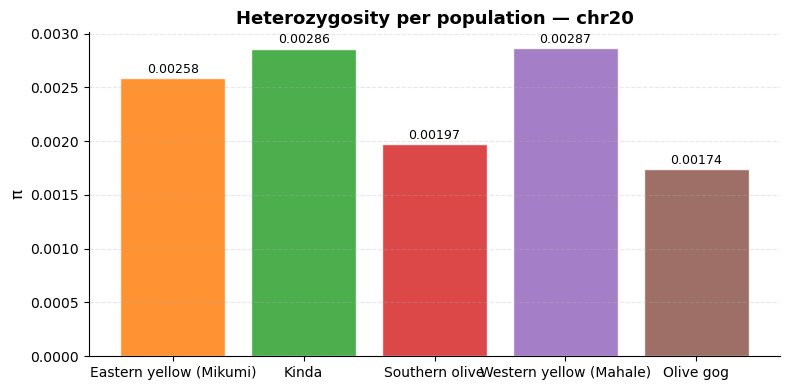

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['C1', 'C2', 'C3', 'C4', 'C5']
bars    = ax.bar(pi_df.index, pi_df["pi"], color=colors, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, pi_df["pi"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.00002,
            f"{val:.5f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("π", fontsize=12)
ax.set_title("Heterozygosity per population — chr20",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 7. Tajima's D

Tajima's D tester om SFS afviger fra neutral evolution i en konstant population.

$$D = \frac{\hat\pi - \hat\theta_W}{\sqrt{\text{Var}(\hat\pi - \hat\theta_W)}}$$

- $D \approx 0$: neutral evolution, konstant population
- $D < 0$: overskud af singletons $\rightarrow$  populationsvækst eller positiv selektion
- $D > 0$: underskud af singletons $\rightarrow$ populationskontraktion eller balancerende selektion

                         Tajima's D            π          θ_W
Eastern yellow (Mikumi)      0.1718  188894.8447  180144.8178
Kinda                        0.0878  209704.2904  204718.3614
Southern olive              -0.1539  143444.4236  150152.5570
Western yellow (Mahale)     -0.1081  218775.3072  224437.3345
Olive gog                   -0.1386  128174.1613  133184.2757

Fortolkning:
  Eastern yellow (Mikumi): D = 0.172 (neutral)
  Kinda: D = 0.088 (neutral)
  Southern olive: D = -0.154 (neutral)
  Western yellow (Mahale): D = -0.108 (neutral)
  Olive gog: D = -0.139 (neutral)


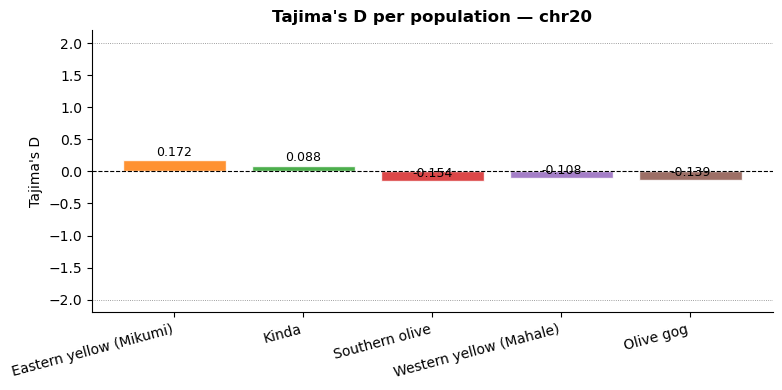

In [28]:
def compute_tajima_d(df):
    """
    Beregner Tajima's D for en population givet derived_count DataFrame.
    Følger Tajima (1989) formlen.
    """
    k_counts = df["derived_count"].values
    n = int(df["nr_samples"].max())
    S = len(df)  # antal segregerende sites

    # pi: gennemsnitlig pairwise diversitet
    pi_hat = (2 * k_counts * (n - k_counts) / (n * (n - 1))).sum()

    # Watterson's theta
    a1 = sum(1 / i for i in range(1, n))
    theta_w = S / a1

    # Variansled (Tajima 1989, eq. 38-40)
    a2 = sum(1 / i**2 for i in range(1, n))
    b1 = (n + 1) / (3 * (n - 1))
    b2 = 2 * (n**2 + n + 3) / (9 * n * (n - 1))
    c1 = b1 - 1 / a1
    c2 = b2 - (n + 2) / (a1 * n) + a2 / a1**2
    e1 = c1 / a1
    e2 = c2 / (a1**2 + a2)

    var_d = e1 * S + e2 * S * (S - 1)
    D = (pi_hat - theta_w) / np.sqrt(var_d) if var_d > 0 else np.nan
    return D, pi_hat, theta_w

tajima_results = {}
for pop_name, df in [
    ("Eastern yellow (Mikumi)", df_yellow_east),
    ("Kinda",                   df_kinda),
    ("Southern olive",          df_olive_south),
    ("Western yellow (Mahale)", df_yellow_west),
    ("Olive gog",               df_olive_gog),
]:
    D, pi_hat, theta_w = compute_tajima_d(df)
    tajima_results[pop_name] = {"Tajima's D": D, "π": pi_hat, "θ_W": theta_w}

tajima_df = pd.DataFrame(tajima_results).T.round(4)
print(tajima_df)
print()
print("Fortolkning:")
for pop, row in tajima_df.iterrows():
    D = row["Tajima's D"]
    sign = "negativ → vækst/selektion" if D < -1 else ("positiv → kontraktion" if D > 1 else "neutral")
    print(f"  {pop}: D = {D:.3f} ({sign})")

fig, ax = plt.subplots(figsize=(8, 4))
colors_t = ['C1', 'C2', 'C3', 'C4', 'C5']
bars = ax.bar(tajima_df.index, tajima_df["Tajima's D"], color=colors_t, alpha=0.85, edgecolor="white")
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(-2, color='grey', lw=0.6, ls=':', label='±2 grænse')
ax.axhline(2,  color='grey', lw=0.6, ls=':')
ax.set_ylabel("Tajima's D")
ax.set_title("Tajima's D per population — chr20", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, tajima_df["Tajima's D"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 8. Gem data

Jeg gemmer de beregnede DataFrames som CSV-filer, så Notebook 04 (two-island model) kan indlæse dem direkte uden at genkøre det hele igen.

In [35]:
df_yellow_east.to_csv(OUT_DIR / "derived_counts_yellow_east.csv", index=False)
df_kinda.to_csv(OUT_DIR       / "derived_counts_kinda.csv",       index=False)
df_yellow_west.to_csv(OUT_DIR / "derived_counts_yellow_west.csv", index=False)
df_olive_south.to_csv(OUT_DIR / "derived_counts_olive_south.csv", index=False)
df_olive_gog.to_csv(OUT_DIR / "derived_counts_olive_gog.csv", index=False)

sfs_ye_f.to_csv(OUT_DIR / "sfs_folded_yellow_east.csv",  header=True)
sfs_ki_f.to_csv(OUT_DIR / "sfs_folded_kinda.csv",         header=True)
sfs_yw_f.to_csv(OUT_DIR / "sfs_folded_yellow_west.csv",  header=True)
sfs_os_f.to_csv(OUT_DIR / "sfs_folded_olive_south.csv",  header=True)
sfs_og_f.to_csv(OUT_DIR / "sfs_folded_olive_gog.csv",  header=True)


pi_df.to_csv(OUT_DIR / "pi_per_population.csv")


print("Gemte filer:")
for f in sorted(OUT_DIR.iterdir()):
    print(" ", f.name)

Gemte filer:
  derived_counts_kinda.csv
  derived_counts_olive_gog.csv
  derived_counts_olive_south.csv
  derived_counts_yellow_east.csv
  derived_counts_yellow_west.csv
  pi_per_population.csv
  sfs_folded_kinda.csv
  sfs_folded_olive_gog.csv
  sfs_folded_olive_south.csv
  sfs_folded_yellow_east.csv
  sfs_folded_yellow_west.csv


I næste notebook 04 — Two-island model, vil jeg bruge de gemte SFS-data til at fitte en to-populations coalescent-model i phasic der modellerer migration mellem fx. eastern yellow baboons og Kinda baboons.